# 분기별 담론 추적: 불용어·TF-IDF 파이프라인

- **입력**: `data/integrated/crolling_total_estate_press.pkl` (blog·카페 통합 후 데이터)
- **Step 0~1**: 명사 `*_raw` 스냅샷 → `config/stopwords/`의 공통 사전으로 `*_clean`
- **Step 2**: 전체 코퍼스 TF-IDF → `outputs/pipeline/`에 CSV
- **Step 3**: 섹션별 로컬 사전 → `*_final`, `nouns_final`
- **Step 4~5**: 시각화 및 `data/integrated/crolling_total_estate_press_layered.pkl` 저장

실행 시 **작업 디렉터리**가 `notebooks/` 또는 프로젝트 루트여도 동작하도록 `project_paths`를 사용합니다.

---

### 이 노트북 실행 결과를 읽는 법

- **`print(...)`**: 터미널/출력 창에만 나오고 파일로 남기지 않습니다. 데이터 크기·분포를 빠르게 확인할 때 씁니다.
- **`DataFrame.head()` 등 마지막 표현식**: Jupyter가 표로 보여 줍니다. “상위 몇 행이 어떤 모양인지” 확인용입니다.
- **`outputs/pipeline/`에 저장되는 CSV·PNG**: 디스크에 쓰이므로, 탐색기나 VS Code에서 열어 엑셀·이미지로 볼 수 있습니다. **코드만 수정했다고 자동 갱신되지 않고**, 해당 셀을 다시 실행해야 덮어씁니다.
- **`data/integrated/*.pkl`**: Python에서만 `pickle.load`로 열 수 있는 통합 결과물입니다.


### (선택) 패키지 설치
환경에 `seaborn`, `wordcloud` 등이 없으면 터미널에서 설치한 뒤 노트북을 다시 시작하세요.
```bash
pip install -r ../requirements_pipeline.txt
```


In [62]:
# =============================================================================
# 경로·라이브러리 로드
# =============================================================================
# [실행 시 나오는 것] 보통 출력 없음. 에러가 나면 project_paths.py 위치나 폴더 구조를 확인하세요.
#
# [의미] PKL·불용어·CSV 저장 위치를 한곳에서 맞춥니다.
#   - PKL_IN / PKL_OUT : 통합 데이터 (blog+카페 등)
#   - STOP_COMMON + STOP_KO : 글로벌 불용어 두 파일을 합쳐 Step 1에 사용
#   - OUT_DIR : TF-IDF·빈도·그림 결과물 → outputs/pipeline/
# =============================================================================

from pathlib import Path
import sys

_cwd = Path.cwd().resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "code"))

# `code/stopword_utils.py`를 저장한 뒤에도, 이전에 import된 모듈이 남아 있으면
# 새 이름(sticky_candidates_per_section 등)이 없다고 나올 수 있어 캐시를 비웁니다.
sys.modules.pop("stopword_utils", None)

from project_paths import DATA_INTEGRATED, CONFIG_STOPWORDS, OUTPUTS_PIPELINE
from stopword_utils import (
    load_stopword_files,
    ensure_token_list,
    snapshot_noun_columns,
    apply_global_clean,
    row_merged_tokens,
    parse_comment_list_cell,
    safe_int_comment_cnt,
    apply_local_clean,
    section_mean_tfidf_matrix,
    unique_keyword_scores,
    document_frequency_from_texts,
    sticky_candidates_per_section,
)
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

OUT_DIR = OUTPUTS_PIPELINE
OUT_DIR.mkdir(parents=True, exist_ok=True)

PKL_IN = DATA_INTEGRATED / "crolling_total_estate_press.pkl"
PKL_OUT = DATA_INTEGRATED / "crolling_total_estate_press_layered.pkl"
STOP_COMMON = CONFIG_STOPWORDS / "stopwords_common.txt"
STOP_KO = CONFIG_STOPWORDS / "stopwords-ko.txt"

## Step 0 — 로드 및 검증


In [63]:
# =============================================================================
# 통합 PKL 로드 + 명사 컬럼 형식 통일
# =============================================================================
# [실행 시 나오는 것]
#   - shape (행수, 열수) : 전체 게시글(문서) 개수와 원본 컬럼 수
#   - columns 리스트 : title, doc, section, 명사 3종 등 원본 스키마
#   - section 값 카운트 : 분기(1~4)별 문서 수 — 어느 분기에 글이 많은지
#   - ch 값 카운트 : blog / cafe 등 채널 비중 (1구간 등 이상치는 다음 마크다운 아래 셀에서 cafe로 고쳐 PKL 저장)
#   - non-list after ensure: 0 이면 명사 컬럼이 모두 리스트로 잘 읽힌 것
# =============================================================================

with open(PKL_IN, "rb") as f:
    df = pickle.load(f)

for c in ["title_token_noun", "document_token_noun", "comment_token_noun"]:
    df[c] = df[c].map(ensure_token_list)

assert isinstance(df, pd.DataFrame), type(df)
print("shape", df.shape)
print(df.columns.tolist())
print(df["section"].value_counts().sort_index())
print(df["ch"].value_counts().head())

for c in ["title_token_noun", "document_token_noun", "comment_token_noun"]:
    bad = (~df[c].map(lambda x: isinstance(ensure_token_list(x), list))).sum()
    print(c, "non-list after ensure:", bad)

shape (8972, 11)
['title', 'doc', 'like', 'comment_cnt', 'comment_list', 'ch', 'date', 'section', 'title_token_noun', 'document_token_noun', 'comment_token_noun']
section
1    2303
2    2419
3    3017
4    1233
Name: count, dtype: int64
ch
blog    5234
cafe    3738
Name: count, dtype: int64
title_token_noun non-list after ensure: 0
document_token_noun non-list after ensure: 0
comment_token_noun non-list after ensure: 0


- 시계열 분포: 3구간(3,017건)에서 데이터가 가장 집중되어 있고, 4구간(1,233건)에서 급감하는 양상을 보임
- 해석: 의대 증원 논란이 3구간 시기에 가장 뜨거운 감자였거나, 담론의 정점을 찍었음을 시사.
- 채널 비중: 블로그(5,234건)가 카페(3,712건)보다 약 1.4배 많음

### Raw 스냅샷 (`*_raw`) 및 보조 컬럼


In [64]:
# =============================================================================
# Raw 스냅샷 + 댓글 메타 보조 컬럼
# =============================================================================
# [실행 시 나오는 것]
#   - title/document/comment_token_noun_raw 에 대한 describe():
#       count = 문서(행) 수, mean = 글 한 편당 명사 개수 평균, min/max = 짧은/긴 글 극단값
#       → “본문 명사가 평균 몇 개인지” 대략적 규모 감을 잡을 수 있음
# [DataFrame에 추가되는 열]
#   - *_raw : 이후 불용어 제거와 비교할 “원본 명사” 백업
#   - comment_list_parsed : 댓글 목록을 dict 리스트로 파싱한 것(분석에 쓰려면)
#   - comment_cnt_int : 댓글 수를 숫자로 통일
# =============================================================================

snapshot_noun_columns(df)

df["comment_list_parsed"] = df["comment_list"].map(parse_comment_list_cell)
df["comment_cnt_int"] = df["comment_cnt"].map(safe_int_comment_cnt)

for c in ["title_token_noun_raw", "document_token_noun_raw", "comment_token_noun_raw"]:
    print(c, df[c].map(len).describe())

title_token_noun_raw count    8972.000000
mean        6.278199
std         4.133051
min         0.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        31.000000
Name: title_token_noun_raw, dtype: float64
document_token_noun_raw count    8972.000000
mean      307.304837
std       481.142333
min         0.000000
25%        61.750000
50%       183.000000
75%       360.000000
max      5382.000000
Name: document_token_noun_raw, dtype: float64
comment_token_noun_raw count    8972.000000
mean       77.594851
std       174.860200
min         0.000000
25%         6.000000
50%        19.000000
75%        68.000000
max      3229.000000
Name: comment_token_noun_raw, dtype: float64


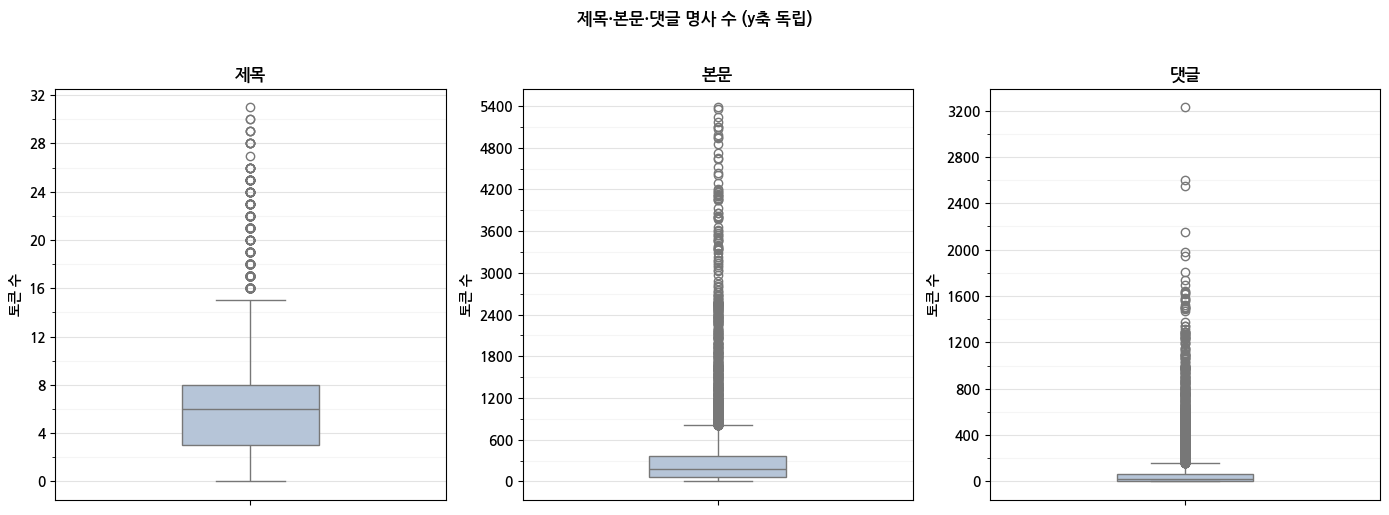

In [65]:
# =============================================================================
# Raw 스냅샷 직후: 제목·본문·댓글 명사 개수(행별 리스트 길이) boxplot
# =============================================================================
# 한글: 프로젝트 루트 아래 nanum-gothic/NanumGothicBold.ttf (구 file_path + 'nanum-gothic/...')
# =============================================================================

from matplotlib import font_manager

_nanum_ttf = PROJECT_ROOT / "nanum-gothic" / "NanumGothicBold.ttf"
if not _nanum_ttf.is_file():
    raise FileNotFoundError(
        f"나눔고딕 폰트가 없습니다: {_nanum_ttf}\n"
        "프로젝트 루트에 nanum-gothic/NanumGothicBold.ttf 를 두세요."
    )
font_manager.fontManager.addfont(str(_nanum_ttf))
_nanum_name = font_manager.FontProperties(fname=str(_nanum_ttf)).get_name()
plt.rcParams["font.family"] = [_nanum_name]
plt.rcParams["axes.unicode_minus"] = False

plot_df = pd.DataFrame(
    {
        "제목": df["title_token_noun_raw"].map(len),
        "본문": df["document_token_noun_raw"].map(len),
        "댓글": df["comment_token_noun_raw"].map(len),
    }
)

# 한 figure에 3개 박스 — y축 범위를 각각 독립(본문 이상치가 제목·댓글 축을 눌러서 박스가 안 보이는 문제 방지)
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
cols = ["제목", "본문", "댓글"]
for ax, col in zip(axes, cols):
    sns.boxplot(y=plot_df[col], ax=ax, width=0.35, color="lightsteelblue")
    ax.set_title(col)
    ax.set_ylabel("토큰 수")
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelbottom=False)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=10, min_n_ticks=8))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(True, which="major", axis="y", alpha=0.35)
    ax.grid(True, which="minor", axis="y", alpha=0.12)

fig.suptitle("제목·본문·댓글 명사 수 (y축 독립)", y=1.02)
plt.tight_layout()
plt.show()

1. 데이터 규모 및 정보량 해석
- 제목 (title_token_noun_raw): 평균 약 6개의 명사가 추출
해석: 제목은 압축된 정보를 담고 있으므로, 제목 분석만으로도 핵심 이슈(의대 증원, 파업 등)를 파악하기에 충분한 정보량. 최대 31개인 경우 제목이 매우 긴 뉴스 기사일 가능성이 높다.

- 본문 (document_token_noun_raw): 평균 307개, 최대 5,382개의 명사 추출
해석: 텍스트 데이터로서 풍부한 정보를 담고있음. 다만, 표준편차(std)가 481로 평균보다 크다는 것은 글의 길이가 매우 짧은 게시글부터 아주 긴 논평형 글까지 편차가 극심함을 의미. 
#### -> 나중에 "너무 짧은 글"은 분석에서 제외할지 고민 필요

- 댓글 (comment_token_noun_raw): 평균 77개의 명사 추출
해석: 본문 대비 약 1/4 수준의 정보량입니다. 댓글은 대중의 직접적인 감정이 드러나는 곳.

2. 데이터 특이사항 점검
min 값이 모두 0인 데이터들이 존재합니다.
해석: 명사가 하나도 추출되지 않은 행들입니다. 사진만 있는 게시글이거나 광고성 글일 수 있습니다.
#### -> 불용어 처리 단계 이후에도 명사가 0개인 행은 최종 분석(TF-IDF 등)에서 dropna 처리

## Step 1 — Global cleaning (`*_clean`)


In [66]:
# =============================================================================
# 글로벌 불용어 적용 → *_clean, corpus_clean
# =============================================================================
# [실행 시 나오는 것]
#   - merged stopword count : common + ko 에서 읽어 합친 불용어 개수 (많을수록 제거 후 토큰이 줄어듦)
#   - corpus_clean 토큰 개수 describe() : 글 한 편당 “정제 후” 남은 명사 토큰 수 분포
#       raw 대비 mean이 줄었으면 불용어가 잘 먹은 것
# [DataFrame에 추가되는 열]
#   - title/document/comment_token_noun_clean
#   - corpus_clean : 한 행 = 한 문서, 제목+본문+댓글 명사를 공백으로 이은 문자열 (TF-IDF 입력)
# =============================================================================

global_sw = load_stopword_files(STOP_COMMON, STOP_KO)
print("merged stopword count:", len(global_sw))

apply_global_clean(df, global_sw, src_suffix="_raw", dst_suffix="_clean")

df["corpus_clean"] = df.apply(lambda r: row_merged_tokens(r, suffix="_clean"), axis=1)
print(df["corpus_clean"].str.split().map(len).describe())

merged stopword count: 787
count    8972.000000
mean      330.883081
std       445.185777
min         0.000000
25%       108.000000
50%       211.000000
75%       377.000000
max      4876.000000
Name: corpus_clean, dtype: float64


- merged stopword count: 733
    - 해석: 범용적인 한국어 불용어와 직접 정의한 도메인 특화 불용어를 합쳐 총 733개의 금칙어 목록 생성

- corpus_clean 통계값 (Mean: 347.99):
    - 해석: 이전 단계의 본문 명사 평균이 307개였는데, 제목과 댓글 명사까지 합쳐진 corpus_clean의 평균이 347개로 나타났습니다.
    - 진단: 불용어 733개를 거쳤음에도 불구하고 한 문서당 약 348개의 유의미한 명사 토큰이 남았다는 것은, 분석에 방해되는 소음은 제거되면서도 핵심 정보량은 여전히 충분히 유지되고 있다는 아주 긍정적인 신호입니다. TF-IDF나 토픽 모델링을 돌리기에 최적의 상태입니다.

## Step 2 — 섹션별 TF-IDF


In [67]:
# =============================================================================
# TF-IDF 행렬 + 섹션별 평균 점수 표 (wide)
# =============================================================================
# [실행 시 나오는 것]
#   - wide shape (용어 수, 4) : 어휘(행) × 섹션 1~4 평균 TF-IDF
#   - 미리보기 표 : 섹션별 평균 TF-IDF 중 **최댓값** 기준 내림차순 상위 15행. 인덱스=단어, 열=분기별 평균 TF-IDF
#       값이 클수록 “그 분기 문서 전체”에서 그 단어가 상대적으로 중요
# [저장 파일] outputs/pipeline/tfidf_section_mean_wide.csv
#       → 엑셀로 열어 특정 단어를 검색하거나 정렬해 비교하기 좋음
# =============================================================================

texts = df["corpus_clean"].tolist()
sections = df["section"].to_numpy()

wide_tfidf, vec, X = section_mean_tfidf_matrix(
    texts, sections, section_ids=(1, 2, 3, 4), min_df=2, max_df=0.98
)
print("wide shape", wide_tfidf.shape)

# CSV·표: 4개 섹션 중 **최대 평균 TF-IDF** 기준 내림차순(어느 분기에서든 두드러진 단어가 위로)
_wide_sorted = (
    wide_tfidf.assign(_peak=wide_tfidf.max(axis=1))
    .sort_values("_peak", ascending=False)
    .drop(columns="_peak")
)
_wide_sorted.to_csv(OUT_DIR / "tfidf_section_mean_wide.csv", encoding="utf-8-sig")

_wide_sorted.head(15)

wide shape (32610, 4)


,section_1_mean_tfidf,section_2_mean_tfidf,section_3_mean_tfidf,section_4_mean_tfidf
의료,0.082128,0.050416,0.043012,0.030853
정부,0.053506,0.038721,0.027218,0.021757
정원,0.051230,0.028344,0.019003,0.027236
병원,0.045129,0.028610,0.027872,0.019729
지역,0.038160,0.027669,0.020202,0.023075
수능,0.016802,0.020866,0.036560,0.027238
입시,0.019688,0.026958,0.027238,0.036289
대학,0.035781,0.033616,0.030643,0.032213
전공의,0.035445,0.019250,0.017573,0.011110
전형,0.019345,0.032157,0.028059,0.027831


In [68]:
# =============================================================================
# 섹션별 “고유 키워드” 후보 CSV
# =============================================================================
# [실행 시 나오는 것]
#   - section 1~4 각각 한 줄씩: 그 분기에서 diff 점수가 가장 큰 단어 이름과 숫자
#       diff = (이 분기 평균 TF-IDF) − (다른 분기들 중 최댓값)
#       → 크면 “다른 분기보다 이 시기에만 두드러지는 단어” 후보
# [저장 파일] outputs/pipeline/unique_keyword_candidates_section{1..4}.csv
#       각 파일 상위 80행: 해당 분기 특이어 후보 리스트
# =============================================================================

scored = unique_keyword_scores(wide_tfidf, section_ids=(1, 2, 3, 4))
for s in (1, 2, 3, 4):
    col = f"diff_vs_others_max_s{s}"
    top = scored.sort_values(col, ascending=False).head(80)
    top.to_csv(OUT_DIR / f"unique_keyword_candidates_section{s}.csv", encoding="utf-8-sig")
    print("section", s, "top diff term:", top.index[0], float(top.iloc[0][col]))

section 1 top diff term: 의료 0.03171149873128758
section 2 top diff term: 휴진 0.017902722963282432
section 3 top diff term: 수시 0.010413771595950718
section 4 top diff term: 복귀 0.017383413535290233


- Wide Shape (32663, 4):
    - 해석: 전체 데이터셋에서 최소 2번 이상 등장한 유효 단어가 총 32,663개라는 뜻
- Diff 점수 로직 (Unique Keyword Scores):
    - 해석: 단순히 TF-IDF가 높은 단어를 뽑으면 '의사', '정부'처럼 늘 나오는 단어만 보입니다. (현재 분기 점수) - (다른 분기 중 최댓값)을 계산함으로써, 다른 시기에는 조용하다가 오직 그 시기에만 폭발한 '특이어(Unique Term)'를 확인

#### 섹션별 핵심 키워드 해석: "의대 사태의 연대기"
- Section 1: "의료" (0.031)
    - 분석: 사태 초기, 정책의 본질인 '의료' 시스템과 증원 논의 자체에 담론이 집중되었음을 보여줍니다. 4개 섹션 중 가장 높은 점수(0.031)를 기록한 것으로 보아 초기 여론의 에너지가 가장 컸습니다.

- Section 2: "휴진" (0.017)
    - 분석: 갈등이 심화되면서 '의료진의 집단 행동(휴진)'이 본격적인 사회적 이슈로 부상했음을 의미합니다. 담론이 정책에서 행동으로 옮겨갔습니다.

- Section 3: "수시" (0.010)
    - 분석: 시기적으로 입시철이 다가오면서, 의대 증원이 실제 교육 현장(수시 모집)에 미치는 영향으로 대중의 관심사가 이동했습니다. 수험생 카페 데이터의 영향.

- Section 4: "복귀" (0.017)
    - 분석: 사태가 장기화되면서 전공의나 학생들의 현장 복귀 여부가 가장 핵심적인 쟁점이 되었음을 시사합니다.

In [69]:
# =============================================================================
# “도메인 고착어” 후보 (자주 나오지만 TF-IDF로는 덜 특이한 단어)
# =============================================================================
# [실행 시 나오는 것]
#   - 마지막 표 15행: sticky_score 상위. doc_freq 큰데 max_section_mean_tfidf는 낮은 패턴
#       → 여러 분기에 골고루 나와서 “당연히 자주 나오는 주제어”일 수 있음 (불용어 후보)
# [저장 파일] outputs/pipeline/sticky_keyword_candidates.csv (상위 200행)
# =============================================================================

df_counts = document_frequency_from_texts(texts)
max_tfidf = wide_tfidf.max(axis=1)
mean_tfidf = wide_tfidf.mean(axis=1)
sticky = pd.DataFrame(
    {
        "doc_freq": df_counts.reindex(wide_tfidf.index).fillna(0).astype(int),
        "max_section_mean_tfidf": max_tfidf,
        "mean_section_mean_tfidf": mean_tfidf,
    }
)
sticky["sticky_score"] = sticky["doc_freq"] / (1.0 + sticky["max_section_mean_tfidf"] * 1000)
sticky.sort_values("sticky_score", ascending=False).head(200).to_csv(
    OUT_DIR / "sticky_keyword_candidates.csv", encoding="utf-8-sig"
)
sticky.sort_values("sticky_score", ascending=False).head(15)

,doc_freq,max_section_mean_tfidf,mean_section_mean_tfidf,sticky_score
마지막,1149,0.004933,0.004356,193.653656
준비,2646,0.012721,0.011441,192.836572
관리,1361,0.006077,0.005667,192.314557
방향,1122,0.004834,0.004273,192.310420
기회,1485,0.006735,0.005969,191.991403
목표,1291,0.005735,0.005354,191.674766
차이,1190,0.005233,0.004810,190.922192
생활,1089,0.004712,0.004159,190.664829
실제,806,0.003236,0.002775,190.258973
도움,1666,0.007764,0.006363,190.088611


### 섹션별 고착어 후보 (분기 코퍼스 각각)

통합 `sticky_keyword_candidates.csv`는 **4개 섹션을 한 TF-IDF 행렬**에 올린 뒤 뽑은 후보입니다. 아래 셀은 **`section` 값별로 문서만** 모아 그 분기 안에서만 `TfidfVectorizer`를 `fit`하고, 문서 빈도(DF)는 높고 평균 TF-IDF는 낮은 용어를 정렬합니다.

- **쓰는 법**: `outputs/pipeline/sticky_keyword_candidates_section{n}.csv`를 열어, 워드클라우드에서만 지우고 싶은 노이즈를 `config/stopwords/stopwords_local_section{n}.txt`에 한 줄에 하나씩 넣은 뒤 **Step 3 이하**를 다시 실행합니다.
- **섹션 1·2**: 담론이 고르게 퍼져 있으면 통합 TF-IDF만으로는 강조 단어가 약해질 수 있어, **섹션 내부** 고착어를 로컬 불용어로 빼 주면 나머지 패턴이 더 잘 드러납니다.

In [70]:
# =============================================================================
# 섹션별 고착어 후보 → CSV
# =============================================================================
sticky_by_sec = sticky_candidates_per_section(
    texts,
    df["section"].to_numpy(),
    section_ids=(1, 2, 3, 4),
    min_df=2,
    max_df=0.98,
    top_n=200,
)
for s, tbl in sticky_by_sec.items():
    path = OUT_DIR / f"sticky_keyword_candidates_section{s}.csv"
    if tbl.empty:
        print(f"section {s}: 빈 테이블 (해당 섹션 문서 부족)")
    else:
        tbl.to_csv(path, encoding="utf-8-sig")
        print(f"section {s}: 저장 {path}  rows={len(tbl)}  sticky 1위: {tbl.index[0]!r}")
print("\n--- 섹션 1 상위 ---\n", sticky_by_sec[1].head(12))
print("\n--- 섹션 2 상위 ---\n", sticky_by_sec[2].head(12))

section 1: 저장 /Users/hyerimchoi/DJD/datacrolling/의대증원_중간프로젝트/outputs/pipeline/sticky_keyword_candidates_section1.csv  rows=200  sticky 1위: '마련'
section 2: 저장 /Users/hyerimchoi/DJD/datacrolling/의대증원_중간프로젝트/outputs/pipeline/sticky_keyword_candidates_section2.csv  rows=200  sticky 1위: '수준'
section 3: 저장 /Users/hyerimchoi/DJD/datacrolling/의대증원_중간프로젝트/outputs/pipeline/sticky_keyword_candidates_section3.csv  rows=200  sticky 1위: '결정'
section 4: 저장 /Users/hyerimchoi/DJD/datacrolling/의대증원_중간프로젝트/outputs/pipeline/sticky_keyword_candidates_section4.csv  rows=200  sticky 1위: '실제'

--- 섹션 1 상위 ---
     doc_freq  mean_tfidf_in_corpus  sticky_score
마련       379              0.004826     65.056725
도움       382              0.005240     61.218803
기준       562              0.008227     60.909152
개인       521              0.007571     60.785814
현실       651              0.009779     60.397496
예정       454              0.006528     60.309194
모습       347              0.004784     59.989572
하루       687  

1. sticky_score 로직 수학적 해석
- 이 로직은 자주 나오는데(doc_freq↑), 시기별 특징은 없는(max_tfidf↓) 단어를 찾아내기 위해 설계되었습니다.
    - 분자 (doc_freq): 이 단어가 얼마나 많은 문서에 골고루 퍼져 있는가? (보편성)
    - 분모 (1.0 + max_tfidf * 1000): 이 단어가 특정 섹션에서 유독 튀는 성질(특이성)이 있는가?
    - 해석: max_tfidf가 낮을수록(즉, 섹션별 변별력이 없을수록) 분모가 작아져 전체적인 sticky_score가 치솟습니다. 즉, 사태의 본질과는 상관없이 습관적으로 쓰이는 배경 소음 같은 단어를 검거하는 공식

2. 출력된 "도메인 고착어" 결과 해석
    - 일반 부사/명사: 전체, 시작, 상태, 대부분, 최근, 사실, 주요
    - 절차적 단어: 포함, 제외, 기간, 해당, 확인, 처음

## Step 3 — 로컬 불용어 및 `nouns_final`


In [71]:
# =============================================================================
# 섹션별 로컬 불용어 → *_final, nouns_final
# =============================================================================
# [실행 시 나오는 것]
#   - nouns_final 토큰 개수 describe() : 최종 분석용으로 남은 명사 수 분포 (글로벌+로컬 제거 후)
# [DataFrame에 추가되는 열]
#   - *_final : config/stopwords/stopwords_local_section{n}.txt 에서 section=n 인 행만 추가 제거
#   - corpus_final : 최종 토큰을 공백 연결한 문자열
#   - nouns_final : 세 필드 명사를 한 리스트로 합친 것 (워드클라우드·빈도에 사용)
# =============================================================================

apply_local_clean(df, CONFIG_STOPWORDS, src_suffix="_clean", dst_suffix="_final")
df["corpus_final"] = df.apply(lambda r: row_merged_tokens(r, suffix="_final"), axis=1)
print(df["nouns_final"].map(len).describe())

count    8972.000000
mean      304.369929
std       414.896746
min         0.000000
25%       100.000000
50%       193.000000
75%       343.000000
max      4563.000000
Name: nouns_final, dtype: float64


## Step 4 — 빈도, WordCloud, 히트맵


In [72]:
# =============================================================================
# 섹션별 단어 빈도 상위 + CSV 저장
# =============================================================================
# [실행 시 나오는 것]
#   - section 1~4 각각 (단어, 빈도) 튜플 리스트 15개 : 그 분기 nouns_final에서 가장 많이 나온 단어
# [저장 파일] outputs/pipeline/section_top_word_frequency.csv
#       section, rank, word, count — 분기별 상위 100개를 한 파일에 길게 쌓음
# =============================================================================

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

plt.rcParams["font.sans-serif"] = ["AppleGothic", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


def top_freq_for_section(sec, k=25):
    sub = df.loc[df["section"] == sec, "nouns_final"]
    flat = [w for row in sub for w in row]
    return Counter(flat).most_common(k)


rows = []
for s in (1, 2, 3, 4):
    for rank, (w, cnt) in enumerate(top_freq_for_section(s, 100), 1):
        rows.append({"section": s, "rank": rank, "word": w, "count": cnt})
    print("section", s, top_freq_for_section(s, 15))
pd.DataFrame(rows).to_csv(OUT_DIR / "section_top_word_frequency.csv", index=False, encoding="utf-8-sig")

section 1 [('의료', 14739), ('정부', 9157), ('정원', 7383), ('병원', 7358), ('대학', 6226), ('지역', 5330), ('국민', 4555), ('전공의', 4502), ('환자', 4277), ('진료', 3668), ('교수', 3600), ('필수', 3531), ('정책', 3377), ('지방', 3274), ('학생', 2867)]
section 2 [('의료', 8952), ('정부', 7001), ('대학', 6715), ('전형', 4931), ('지역', 4441), ('정원', 4378), ('병원', 4376), ('학생', 3784), ('국민', 3639), ('입시', 3494), ('모집', 3330), ('교수', 3258), ('수능', 2987), ('지원', 2733), ('전공', 2616)]
section 3 [('의료', 10811), ('대학', 7502), ('정부', 6707), ('병원', 6282), ('전형', 5682), ('수능', 5508), ('학생', 5197), ('지원', 4943), ('수시', 4806), ('입시', 4691), ('지역', 4627), ('교육', 4181), ('모집', 4027), ('국민', 3962), ('감사', 3919)]
section 4 [('대학', 3095), ('의료', 2884), ('감사', 2261), ('전형', 2233), ('학생', 2196), ('입시', 2140), ('수능', 1872), ('정원', 1834), ('정부', 1781), ('지역', 1721), ('병원', 1585), ('모집', 1524), ('지원', 1480), ('학교', 1450), ('정시', 1373)]


1. 섹션별 담론의 중심축 이동 (Key Findings)
- Section 1: [의료 정책과 시스템의 충돌]
    - 핵심어: 의료(14,739), 정부(9,157), 정원(7,383), 병원, 대학
    - 해석: '의료'와 '정부'가 압도적인 빈도를 차지하며 사태의 시작점인 정책적 대립을 선명하게 보여줍니다. '정원' 키워드의 부상은 증원 규모에 대한 논란이 1구간의 핵심이었음을 증명합니다.

- Section 2: [입시와 대학 행정으로의 전이]
    - 핵심어: 의료(8,952), 대학, 전형(4,931), 지역, 정원
    - 해석: 1구간에 비해 '의료' 빈도는 줄어든 반면, **'전형', '대학'**의 순위가 급상승했습니다. 이는 의료 대란 담론이 교육계의 실무적인 입시 전형 문제로 구체화되었음을 시사합니다.

- Section 3: [수험생 여론과 교육 이슈의 정점]
    - 핵심어: 의료, 대학, 정부, 전형, 수능(5,508), 학생, 지원, 수시(4,806)
    - 해석: '수능', '수시', '학생', '모집' 등 입시 관련 키워드가 상위권을 완전히 장악했습니다. 특히 수능(5,508건) 키워드의 등장은 이 시기가 수험생 커뮤니티에서 가장 뜨거운 쟁점이었음을 보여줍니다.

- Section 4: [입시 마무리와 학제 변화]
    - 핵심어: 대학, 의료, 감사(2,261), 입시, 수능, 정원
    - 해석: '감사'라는 새로운 키워드가 등장하며 사태의 사후 처리나 행정적 절차에 대한 담론이 형성되었습니다. 담론의 총량(Count) 자체는 줄었으나, '정원'과 '입시'가 여전히 주요 키워드로 남아 사태의 여파가 지속되고 있음을 보여줍니다.

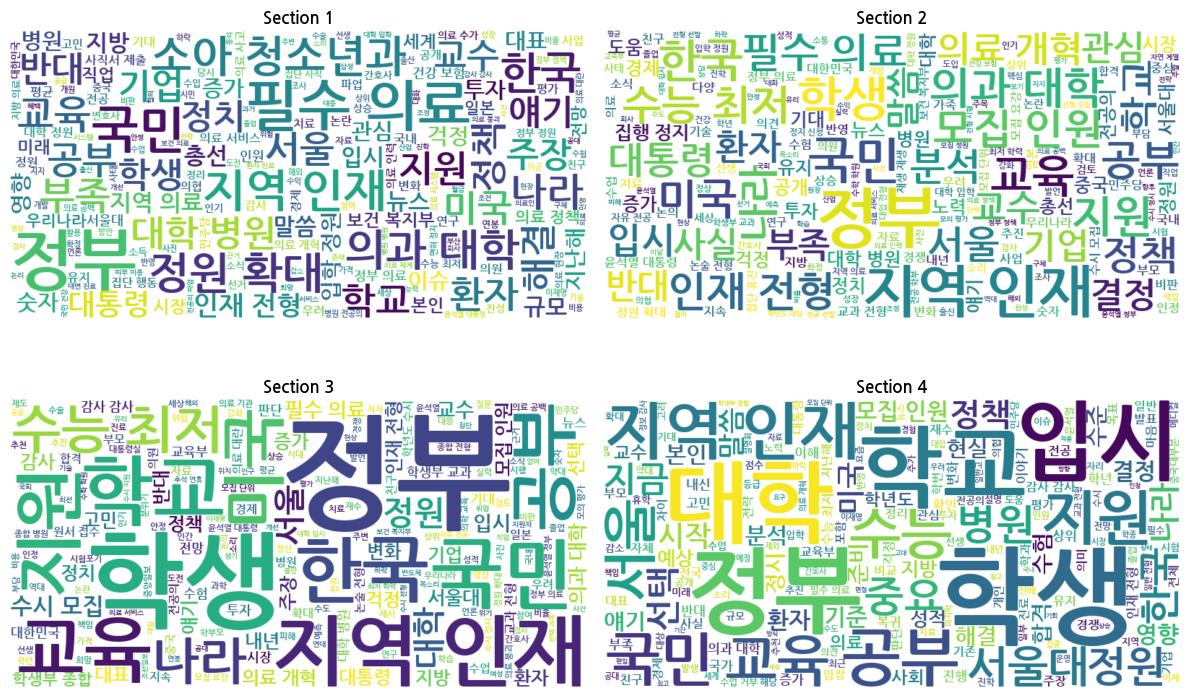

In [59]:
# =============================================================================
# WordCloud (4분기 2×2)
# =============================================================================
# [실행 시 나오는 것]
#   - 그림 창: 분기별로 자주 나온 단어가 크게 보임 (한글 폰트가 없으면 글자가 깨질 수 있음)
# [저장 파일] outputs/pipeline/wordcloud_by_section.png
# [주의] wordcloud 패키지가 없으면 메시지만 출력되고 그림은 생략
# =============================================================================

from wordcloud import WordCloud

if WordCloud:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for i, s in enumerate((1, 2, 3, 4)):
        ax = axes.ravel()[i]
        text = " ".join(w for row in df.loc[df["section"] == s, "nouns_final"] for w in row)
        wc = (
            WordCloud(_nanum_ttf, width=800, height=400, background_color="white").generate(text)
            if text.strip()
            else None
        )
        if wc:
            ax.imshow(wc, interpolation="bilinear")
        else:
            ax.text(0.5, 0.5, "(empty)", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"Section {s}")
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "wordcloud_by_section.png", dpi=150, bbox_inches="tight")
    plt.show()

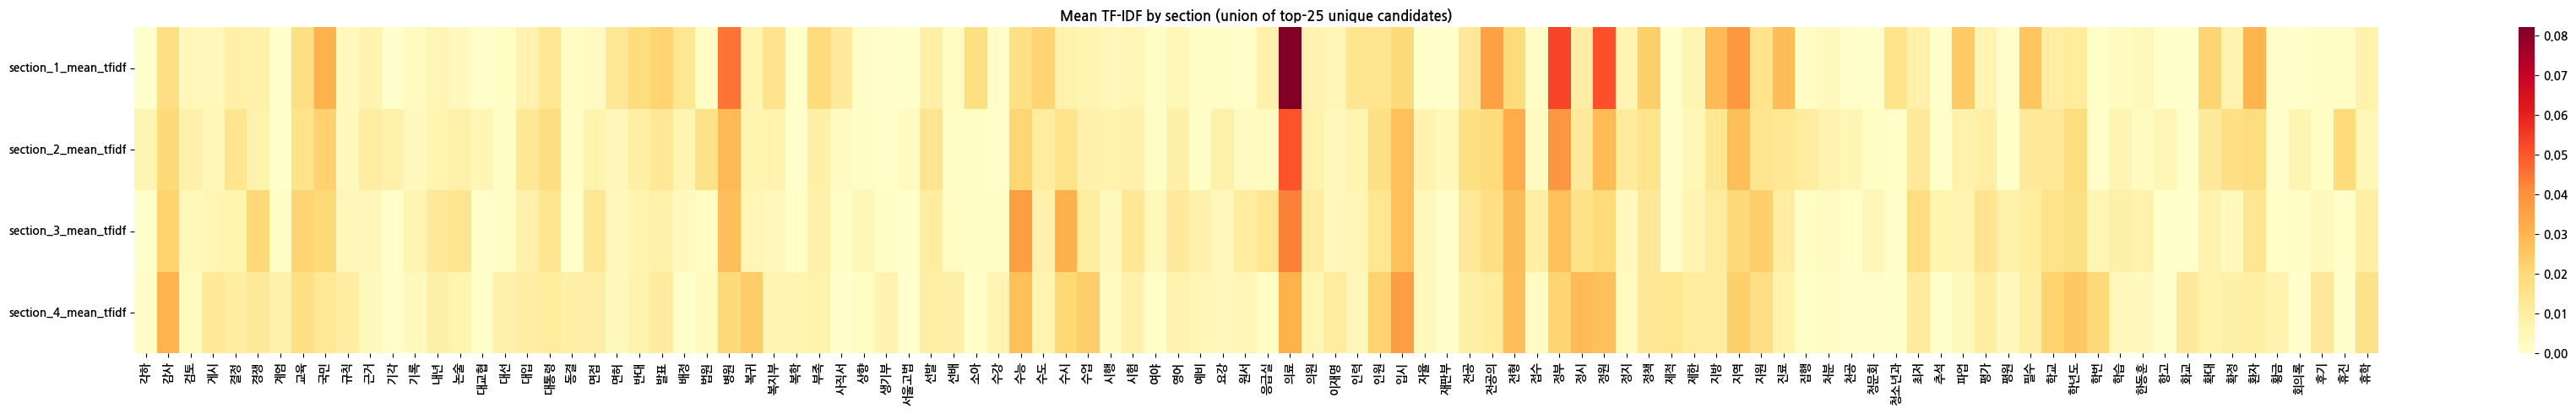

In [73]:
# =============================================================================
# TF-IDF 히트맵 (고유어 후보 union)
# =============================================================================
# [실행 시 나오는 것]
#   - 히트맵: 가로=단어, 세로=section_1~4 평균 TF-IDF 행. 색이 진할수록 그 분기에서 점수 높음
# [저장 파일] outputs/pipeline/tfidf_heatmap_union_top.png
# =============================================================================

union_terms = set()
for s in (1, 2, 3, 4):
    union_terms.update(scored.sort_values(f"diff_vs_others_max_s{s}", ascending=False).head(25).index)
union_terms = sorted(union_terms)
heat = wide_tfidf.reindex(union_terms).T
plt.figure(figsize=(max(10, len(union_terms) * 0.35), 5))
sns.heatmap(heat, cmap="YlOrRd", xticklabels=True)
plt.title("Mean TF-IDF by section (union of top-25 unique candidates)")
plt.tight_layout()
plt.savefig(OUT_DIR / "tfidf_heatmap_union_top.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5 — layered pickle 저장


In [66]:
# =============================================================================
# 최종 DataFrame 저장 (파생 열 포함)
# =============================================================================
# [실행 시 나오는 것]
#   - saved 와 파일 경로 한 줄: 저장 성공 여부 확인용
# [저장 파일] data/integrated/crolling_total_estate_press_layered.pkl
#       raw / clean / final 명사, corpus_*, nouns_final 등 분석에 쓴 열이 모두 들어 있음
#       용량이 클 수 있음 — 필요 없는 열은 나중에 drop 후 다시 저장 가능
# =============================================================================

with open(PKL_OUT, "wb") as f:
    pickle.dump(df, f, protocol=pickle.HIGHEST_PROTOCOL)
print("saved", PKL_OUT)

saved /Users/hyerimchoi/DJD/datacrolling/의대증원_중간프로젝트/data/integrated/crolling_total_estate_press_layered.pkl
